In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
file_path = r'C:\Users\User\OneDrive\Desktop\all_in_one\traditional_ML\classification\heart_attack_risk\Heart_Attack_Risk_Levels_Dataset.csv'

df = pd.read_csv(file_path)
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,negative,Moderate,Monitor closely and consult doctor
1,20,1,94,98,46,296.0,6.75,1.060,positive,High,Immediate medical attention
2,56,1,64,160,77,270.0,1.99,0.003,negative,Moderate,Monitor closely and consult doctor
3,66,1,70,120,55,270.0,13.87,0.122,positive,High,Immediate medical attention
4,54,1,64,112,65,300.0,1.08,0.003,negative,Moderate,Monitor closely and consult doctor
...,...,...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative,Moderate,Monitor closely and consult doctor
1315,66,1,84,125,55,149.0,1.33,0.172,positive,High,Immediate medical attention
1316,45,1,85,168,104,96.0,1.24,4.250,positive,High,Immediate medical attention
1317,54,1,58,117,68,443.0,5.80,0.359,positive,High,Immediate medical attention


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
 9   Risk_Level                1319 non-null   object 
 10  Recommendation            1319 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 113.5+ KB


In [4]:
df['Recommendation'].value_counts()

Recommendation
Immediate medical attention           812
Maintain healthy lifestyle            275
Monitor closely and consult doctor    232
Name: count, dtype: int64

In [5]:
df['Risk_Level'].value_counts()

Risk_Level
High        812
Low         275
Moderate    232
Name: count, dtype: int64

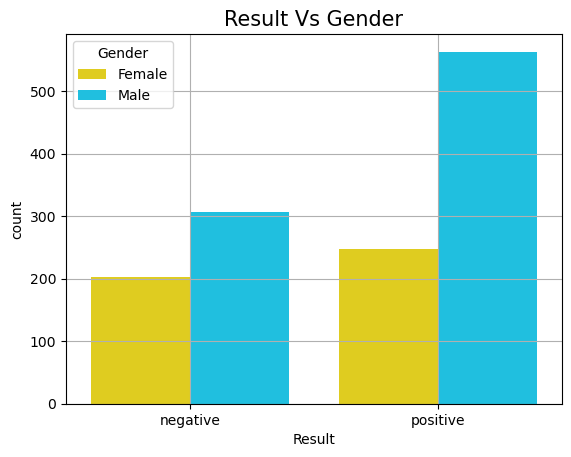

In [6]:
sns.countplot(x=df['Result'], hue=df['Gender'], palette='jet_r')
plt.title('Result Vs Gender', fontsize=15)
plt.legend(title='Gender',labels=['Female','Male'])
plt.grid(True)
plt.show()

In [7]:
mapping_labels = {
    "High" : 3,
    "Moderate" : 2, 
    "Low" : 1,
    "Immediate medical attention" : 3,
    "Monitor closely and consult doctor" : 2,
    "Maintain healthy lifestyle" : 1,
    "negative" : 0,
    "positive" : 1 
}

columns_to_map = ['Result', 'Risk_Level', 'Recommendation']

for column in columns_to_map:
    df[column] = df[column].map(mapping_labels)

In [8]:
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,0,2,2
1,20,1,94,98,46,296.0,6.75,1.060,1,3,3
2,56,1,64,160,77,270.0,1.99,0.003,0,2,2
3,66,1,70,120,55,270.0,13.87,0.122,1,3,3
4,54,1,64,112,65,300.0,1.08,0.003,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0,2,2
1315,66,1,84,125,55,149.0,1.33,0.172,1,3,3
1316,45,1,85,168,104,96.0,1.24,4.250,1,3,3
1317,54,1,58,117,68,443.0,5.80,0.359,1,3,3


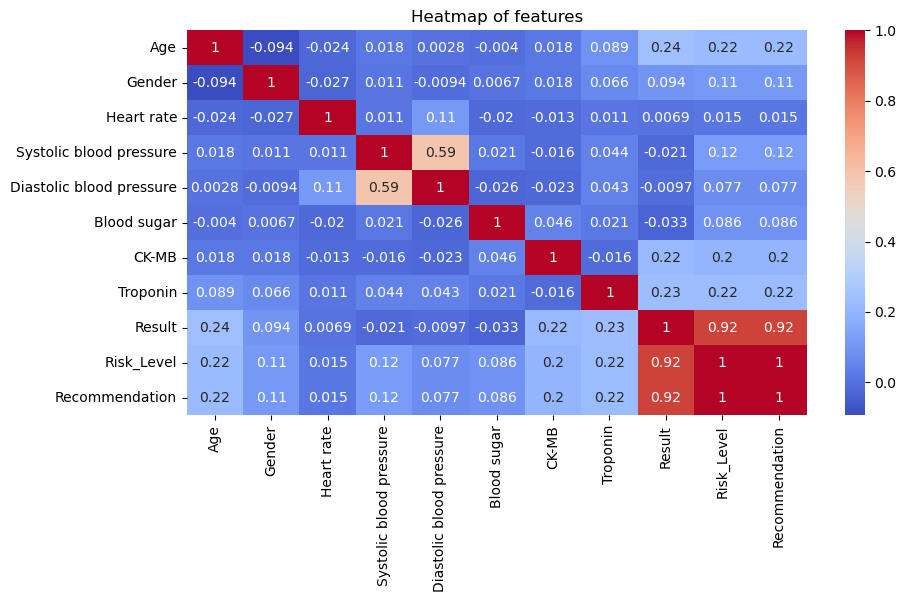

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.title("Heatmap of features")
plt.show()

In [10]:
df.drop('Recommendation', inplace=True, axis=1)

In [11]:
z_scores = df.select_dtypes(include='number').apply(zscore)
outliers = (z_scores.abs() > 3)
df_outliers = df[outliers.any(axis=1)]
df_outliers

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level
7,61,1,60,214,82,87.0,300.000,2.370,1,3
12,64,1,60,199,99,92.0,3.430,5.370,1,3
28,47,0,66,134,57,279.0,300.000,0.007,1,3
29,63,1,66,135,55,166.0,0.493,10.000,0,3
30,54,1,125,131,82,95.0,1.310,8.300,1,3
...,...,...,...,...,...,...,...,...,...,...
1294,50,0,79,92,55,415.0,16.950,0.005,1,3
1302,40,1,57,208,40,108.0,2.110,0.003,0,2
1310,70,0,80,135,75,351.0,2.210,10.000,1,3
1316,45,1,85,168,104,96.0,1.240,4.250,1,3


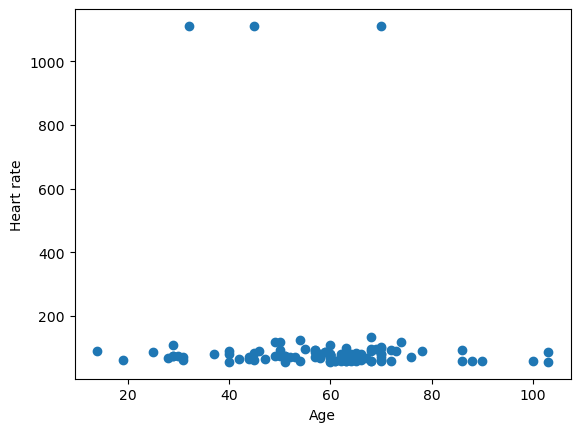

In [12]:
plt.scatter(df_outliers['Age'], df_outliers['Heart rate'])
plt.xlabel('Age')
plt.ylabel('Heart rate')
plt.show()

In [13]:
df[df['Heart rate'] > 800]

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level
63,45,1,1111,141,95,109.0,1.33,1.010,1,3
717,70,0,1111,141,95,138.0,3.87,0.028,1,3
1069,32,0,1111,141,95,82.0,2.66,0.008,0,2


In [14]:
outlier_indexes = df[outliers.any(axis=1)].index
df_normal = df.drop(index=outlier_indexes)

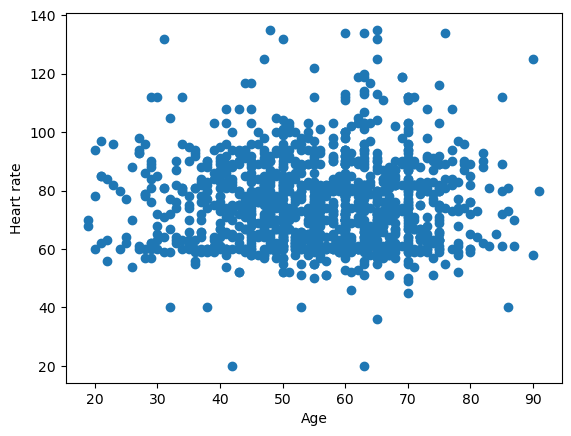

In [15]:
plt.scatter(df_normal['Age'], df_normal['Heart rate'])
plt.xlabel('Age')
plt.ylabel('Heart rate')
plt.show()

In [18]:
X, y = df_normal.drop('Result', axis=1), df_normal['Result'].copy()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

##### modelling

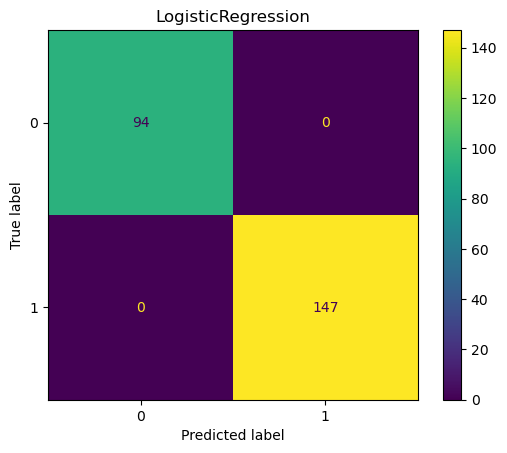

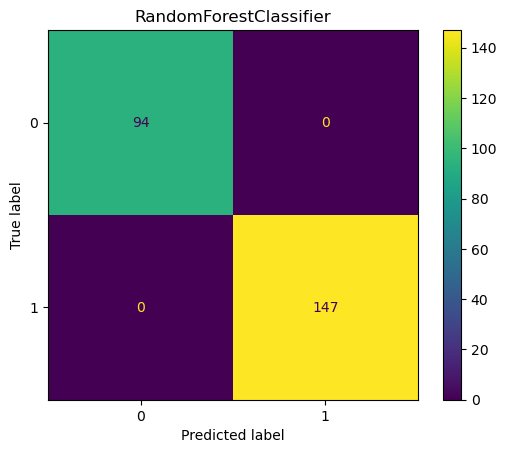

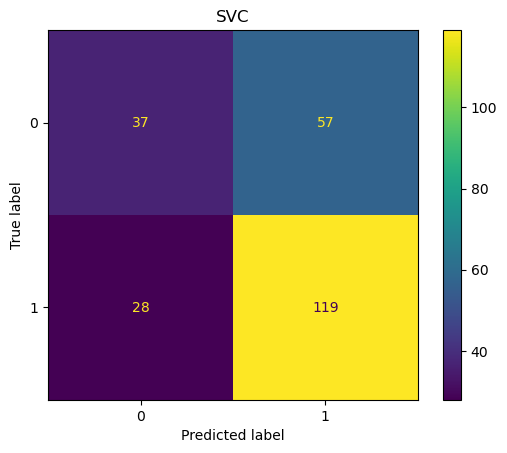

In [28]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM": SVC(random_state=42),
}

results = list()

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred), display_labels=[0,1]).plot()
    plt.title(f'{model.__class__.__name__}')
    results.append({
        "Model": name,
        "Accurancy":acc,
        "Precision":prec,
        "Recall": rec,
        "f1_score": f1,
    })

In [25]:
model_metrics = pd.DataFrame(results)
model_metrics

,Model,Accurancy,Precision,Recall,f1_score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,SVM,0.647303,0.676136,0.809524,0.736842
